# Tutorial: Post-Optimality Sensitivity of AquaHarmonics Power to BEM Parameters

This tutorial demonstrates how to compute **gradients of optimal electrical power with respect to hydrodynamic (BEM) coefficients** for the AquaHarmonics device using the Fiacco/envelope-theorem formula.

We build on [Tutorial 2 -- AquaHarmonics](../examples/tutorial_2_AquaHarmonics.ipynb) (Part 1: optimal control with a loss map) and extend it with post-optimality sensitivity analysis.

1. [Setup](#1.-Setup) -- AquaHarmonics geometry, BEM, PTO with loss map, forces, constraints
2. [Solve with IPOPT](#2.-Solve-with-IPOPT) -- use `WEC_IPOPT` to obtain Lagrange multipliers
3. [Sensitivity Analysis](#3.-Sensitivity-Analysis) -- three equivalent methods, all computed before any manual tracing
   - 3a. `make_differentiable_solver` (JAX-native, runs IPOPT internally)
   - 3b. `sensitivity()` (one-liner convenience)
   - 3c. Manual Fiacco VJP (step-by-step pedagogical)
   - 3d. Cross-check: all three agree
4. [Visualize Sensitivities](#4.-Visualize-Sensitivities) -- per-parameter and per-frequency plots
5. [Finite-Difference Validation](#5.-Finite-Difference-Validation) -- verify the analytical gradient
6. [Summary](#6.-Summary)

### Why this tutorial?

Tutorial 2 features a significantly more complex model than the WaveBot (Tutorial 1):

- **Nonlinear PTO**: generator loss map (Joule heating), gear ratios, pneumatic air spring
- **Multiple constraints**: peak torque, max speed, max power, minimum line tension, zero mean position
- **Additional forces**: PTO passive (inertia, friction, spring), buoyancy, gravity, pretension

Despite this complexity, the Fiacco formula still works because:

- The objective (`pto.average_power`) does not depend on BEM parameters $h$ directly, so $\partial f / \partial h = 0$.
- The additional forces (PTO, buoyancy, gravity, springs) do not depend on BEM parameters, so they contribute zero to $\partial r / \partial h$.
- The inequality constraints also do not depend on $h$, so $\mu^\top \partial g_{\text{ineq}} / \partial h = 0$.

The gradient computation is essentially **free** compared to the IPOPT solve.

## 1. Setup

This section mirrors [Tutorial 2, Part 1](../examples/tutorial_2_AquaHarmonics.ipynb) with one key change: we use `WEC_IPOPT` (which returns Lagrange multipliers needed for the Fiacco formula) instead of `wot.WEC`.

In [23]:
import capytaine as cpy
from capytaine.io.meshio import load_from_meshio
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import wecopttool as wot

# Differentiable sensitivity (IPOPT, Fiacco, sensitivity plots)
from wecopttool_differentiable import (
    WEC_IPOPT,
    sensitivity,
    make_differentiable_solver,
    BEMParams,
    WaveData,
    extract_bem_params,
    extract_wave_data,
    residual_parametric,
    plot_sensitivity_bars,
    plot_frequency_sensitivity,
    plot_fd_comparison,
)

plt.style.use('tableau-colorblind10')
cc = plt.rcParams['axes.prop_cycle'].by_key()['color']

### Geometry and BEM

In [24]:
# Hull mesh
ah_hull = wot.geom.AquaHarmonics()
mesh = ah_hull.mesh(mesh_size_factor=0.25)

# Capytaine FloatingBody
mesh_obj = load_from_meshio(mesh, 'WaveBot')
lid_mesh = mesh_obj.generate_lid(-5e-2)
fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh, name="AquaHarmonics")
fb.add_translation_dof(name="Heave")
ndof = fb.nb_dofs

# Hydrostatics and mass
g = 9.81
rho = 1025
fb.center_of_mass = [0, 0, 0]
fb.rotation_center = fb.center_of_mass
displaced_mass = fb.compute_rigid_body_inertia(rho=rho).values
displacement = displaced_mass / rho
fb.mass = np.atleast_2d(5e3)

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

In [25]:
# Waves
amplitude = 0.5
wavefreq = 0.24 / 2
phase = 30
wavedir = 0

f1 = wavefreq
nfreq = 10

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

In [26]:
# BEM
freq = wot.frequency(f1, nfreq, False)
bem_data = wot.run_bem(fb, freq, rho=rho, g=g)

[13:35:53] WARNING  center_of_mass already defined as [0, 0, 0].

           WARNING  rotation_center already defined as [0, 0, 0].

           WARNING  FloatingBody has no inertia_matrix field. The FloatingBody mass is defined and will be used for
                    calculating the inertia matrix.

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

           WARNING  FloatingBody has no hydrostatic_stiffness field. Capytaine will auto-populate the hydrostatic  
                    stiffness based on the provided mesh.

The resolution of the mesh might be insufficient for omega ranging from 6.786 to 7.540.
This warning appears when the largest panel of this mesh has radius > wavelength/8.


           WARNING  Mesh resolution for 4 problems:                                                                
                    The resolution of the mesh might be insufficient for omega ranging from 6.786 to 7.540.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([dataset, diffraction_cases])
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([d

### PTO with generator loss map

In [27]:
# Drive train parameters
radii = {
    "S1": 0.02, "S2": 0.795, "S3": 0.1595, "S4": 0.200525, "S5": 0.40105,
    "S6": 0.12575, "S7": 0.103
}

inertias = {
    "Igen": 3.9, "I1": 0.029, "I2": 25.6, "I3": 1.43, "I4": 1.165, "I5": 4.99,
    "I6": 1.43, "I7": 1.5, "mps": 40
}

friction = {
    "Bgen": 7, "Bdrivetrain": 40, "Bshaft": 40, "Bspring_pulley": 80,
    "Bpneumatic_spring": 700, "Bpneumatic_spring_static1": 0,
    "Bpspneumatic_spring_static2": 0
}

airspring = {
    "gamma": 1.4, "height": 1, "diameter": 3, "area": 0.0709676,
    "press_init": 854e3, "vol_init": 1
}

gear_ratios = {
    "R21": radii['S2'] / radii['S1'],
    "R45": radii['S4'] / radii['S5'],
    "R67": radii['S6'] / radii['S7'],
    "spring": radii['S6'] * (radii['S4'] / radii['S5'])
}

inertia_pto = (
    (inertias["Igen"] + inertias["I1"]) * gear_ratios['R21']**2 +
    (inertias['I2'] + inertias['I3'] + inertias['I4']) +
    gear_ratios["R45"]**2 * (
        inertias['I5'] + inertias['I6'] +
        inertias["I7"] * gear_ratios['R67']**2 +
        inertias['mps'] * radii['S6']**2
    )
)

friction_pto = (
    friction['Bgen'] * gear_ratios['R21']**2 +
    friction['Bdrivetrain'] +
    gear_ratios["R45"]**2 * (
        friction["Bshaft"] +
        friction["Bspring_pulley"] * gear_ratios['R67']**2 +
        friction["Bpneumatic_spring"] * radii['S6']**2
    )
)

# Generator loss map
winding_resistance = 0.4
torque_coefficient = 1.5

def power_loss(speed, torque):
    return winding_resistance * (torque / torque_coefficient)**2

# Generator limits
rot_max = 10000 * 2 * np.pi / 60
torque_max = 300
power_max = 80e3

In [28]:
# PTO object
name = ["PTO_Heave"]
gear_ratio_generator = gear_ratios['R21'] / radii['S3']
kinematics = gear_ratio_generator * np.eye(ndof)
controller = wot.controllers.unstructured_controller()
nstate_opt = 2 * nfreq
pto_impedance = None
pto = wot.pto.PTO(
    ndof, kinematics, controller, pto_impedance, power_loss, name
)

### Additional forces and constraints

In [29]:
# Additional forces
def f_buoyancy(wec, x_wec, x_opt, wave, nsubsteps=1):
    return displacement * rho * g * jnp.ones([wec.ncomponents * nsubsteps, wec.ndof])

def f_gravity(wec, x_wec, x_opt, wave, nsubsteps=1):
    return -1 * wec.inertia_matrix.item() * g * jnp.ones([wec.ncomponents * nsubsteps, wec.ndof])

def f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps=1):
    f_b = f_buoyancy(wec, x_wec, x_opt, wave, nsubsteps)
    f_g = f_gravity(wec, x_wec, x_opt, wave, nsubsteps)
    return -1 * (f_b + f_g)

def f_pto_passive(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat, pos)
    acc = jnp.dot(wec.derivative_mat, vel)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    spring = -(gear_ratios['spring'] * airspring['gamma'] * airspring['area'] *
              airspring['press_init'] / airspring['vol_init']) * pos
    f_spring = jnp.dot(time_matrix, spring)
    fric = -(friction_pto +
             friction['Bpneumatic_spring_static1'] *
             gear_ratios['spring']) * vel
    f_fric = jnp.dot(time_matrix, fric)
    inertia = inertia_pto * acc
    f_inertia = jnp.dot(time_matrix, inertia)
    return f_spring + f_fric + f_inertia

def f_pto_line(wec, x_wec, x_opt, wave, nsubsteps=1):
    f_pto = pto.force_on_wec(wec, x_wec, x_opt, wave, nsubsteps)
    f_pre = f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps)
    return f_pto + f_pre

f_add = {
    'PTO': f_pto_line,
    'PTO_passive': f_pto_passive,
    'buoyancy': f_buoyancy,
    'gravity': f_gravity,
}

In [30]:
# Constraints
torque_peak_max = 280
rot_speed_max = 10000 * 2 * np.pi / 60
min_line_tension = -1000
nsubsteps = 2

def const_peak_torque_pto(wec, x_wec, x_opt, wave):
    torque = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
    return torque_peak_max - jnp.abs(torque.flatten())

def const_speed_pto(wec, x_wec, x_opt, wave):
    rot_vel = pto.velocity(wec, x_wec, x_opt, wave, nsubsteps)
    return rot_speed_max - jnp.abs(rot_vel.flatten())

def const_power_pto(wec, x_wec, x_opt, wave):
    power_mech = (
        pto.velocity(wec, x_wec, x_opt, wave, nsubsteps) *
        pto.force(wec, x_wec, x_opt, wave, nsubsteps)
    )
    return power_max - jnp.abs(power_mech.flatten())

def constrain_min_tension(wec, x_wec, x_opt, wave):
    total_tension = -1 * f_pto_line(wec, x_wec, x_opt, wave, nsubsteps)
    return total_tension.flatten() + min_line_tension

def zero_mean_pos(wec, x_wec, x_opt, wave):
    return x_wec[0]

constraints = [
    {'type': 'ineq', 'fun': constrain_min_tension},
    {'type': 'ineq', 'fun': const_peak_torque_pto},
    {'type': 'ineq', 'fun': const_speed_pto},
    {'type': 'ineq', 'fun': const_power_pto},
    {'type': 'eq', 'fun': zero_mean_pos},
]

### Create `WEC_IPOPT` object

This is the key difference from Tutorial 2: we use `WEC_IPOPT.from_bem` so that IPOPT returns Lagrange multipliers.

In [31]:
wec = WEC_IPOPT.from_bem(
    bem_data,
    constraints=constraints,
    f_add=f_add,
)

obj_fun = pto.average_power

print(f"nstate_wec = {wec.nstate_wec}")
print(f"nstate_opt = {nstate_opt}")
print(f"ndof       = {wec.ndof}")
print(f"nfreq      = {wec.nfreq}")

[13:36:05] WARNING  Linear damping for DOF "Heave" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

nstate_wec = 20
nstate_opt = 20
ndof       = 1
nfreq      = 10


## 2. Solve with IPOPT

We solve the same optimal control problem as Tutorial 2, but using IPOPT instead of SLSQP. IPOPT returns the Lagrange multipliers $\lambda^*$ that we need for the Fiacco formula.

In [32]:
scale_x_wec = 1e1
scale_x_opt = 50e-2
scale_obj = 1e-3

ipopt_options = {
    'max_iter': 2000,
    'tol': 1e-8,
    'print_level': 5,
}

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    x_wec_0=np.ones(wec.nstate_wec) * 1e-3,
    x_opt_0=np.ones(nstate_opt) * 1e-3,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
    optim_options=ipopt_options,
)

res = results[0]
print(f"\nIPOPT success: {res.success}")
print(f"Message: {res.message}")
print(f"Optimal average electrical power: {res.fun / 1e3:.2f} kW")

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:      840
Number of nonzeros in inequality constraint Jacobian.:     6400
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       40
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       21
Total number of inequality constraints...............:      160
        inequality constraints with only lower bounds:      160
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.9555556e-09 1.64e+04 1.00e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [33]:
print(f'Optimal average power: {results[0].fun/1e3:.2f} kW')

Optimal average power: -1.58 kW


### Inspect Lagrange multipliers

IPOPT returns multipliers for every constraint. The dynamics multipliers $\lambda^*$ are the ones we need for the Fiacco formula.

In [34]:
lam = res.dynamics_mult_g
print(f"Dynamics multipliers shape: {lam.shape}")
print(f"  (should be ({wec.nstate_wec},))")
print(f"max |lambda|: {np.max(np.abs(lam)):.4e}")
print(f"All finite: {np.all(np.isfinite(lam))}")

# Verify the dynamics residual is near zero at the optimum
x_wec, x_opt = wec.decompose_state(res.x)
wav = waves.sel(realization=0)
r = wec.residual(x_wec, x_opt, wav)
print(f"\nmax |residual| at optimum: {np.max(np.abs(r)):.2e}")

# Summary of all constraints
print(f"\nConstraint info:")
for name, info in res.constraint_info.items():
    print(f"  {name}: type={info['type']}, size={info['size']}")

Dynamics multipliers shape: (20,)
  (should be (20,))
max |lambda|: 1.9324e-02
All finite: True

max |residual| at optimum: 1.46e-11

Constraint info:
  user_constraint_0: type=ineq, size=40
  user_constraint_1: type=ineq, size=40
  user_constraint_2: type=ineq, size=40
  user_constraint_3: type=ineq, size=40
  user_constraint_4: type=eq, size=1
  dynamics: type=eq, size=20


## 3. Sensitivity Analysis

We compute the Fiacco sensitivity $d\varphi^*/dh$ using three equivalent methods.

> **Ordering note:** `make_differentiable_solver` runs a fresh IPOPT solve
> internally, so it must execute *before* any standalone `jax.vjp` tracing
> through `residual_parametric`. The manual VJP and `sensitivity()` only
> use the already-computed solution `res` and do not re-solve, so they are
> safe to run in any order after that.

### 3a. JAX-native: `make_differentiable_solver`

`make_differentiable_solver` returns a function `f(bem_params) -> optimal_objective` with a `jax.custom_vjp` registered. The forward pass runs IPOPT, the backward pass uses the Fiacco formula.

This must run first because it needs IPOPT to converge on a fresh state.

In [35]:
# Warm-start from the converged solution
x_wec_star, x_opt_star = wec.decompose_state(res.x)

# Prepare BEM parameters for the differentiable path
hydro_data = wot.add_linear_friction(bem_data, friction=None)
hydro_data = wot.check_radiation_damping(hydro_data)
bp = extract_bem_params(hydro_data)

# Build differentiable solver
f = make_differentiable_solver(
    wec, waves, obj_fun, nstate_opt,
    x_wec_0=np.array(x_wec_star),
    x_opt_0=np.array(x_opt_star),
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
    optim_options={
        'max_iter': 2000, 'tol': 1e-8, 'print_level': 0,
        'warm_start_init_point': 'yes', 'mu_init': 1e-6,
    },
)

# Forward pass -- IPOPT solve
phi_star_vjp = f(bp)
print(f"Forward pass: phi* = {float(phi_star_vjp)/1e3:.2f} kW")

# Backward pass -- Fiacco formula (no differentiation through IPOPT)
grad_vjp = jax.grad(f)(bp)

print("\n=== jax.grad(f) -- custom_vjp Fiacco ===")
for name in BEMParams._fields:
    g = getattr(grad_vjp, name)
    print(f"  {name:30s}  max|grad| = {float(jnp.max(jnp.abs(g))):.4e}")

[13:36:07] WARNING  Linear damping for DOF "Heave" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

Forward pass: phi* = -1.58 kW

=== jax.grad(f) -- custom_vjp Fiacco ===
  added_mass                      max|grad| = 1.8566e-02
  radiation_damping               max|grad| = 7.7200e-02
  hydrostatic_stiffness           max|grad| = 3.2620e-02
  friction                        max|grad| = 7.7232e-02
  Froude_Krylov_force             max|grad| = 9.4990e-02
  diffraction_force               max|grad| = 9.4990e-02
  inertia_matrix                  max|grad| = 1.8337e-02


### 3b. One-liner: `sensitivity()`

The `sensitivity()` method wraps the entire Fiacco computation (extract BEM params, extract wave data, build VJP, etc.) in a single call. It uses the existing solved result — no new IPOPT solve needed.

In [36]:
grad_sens = sensitivity(wec, res, waves)

# Or equivalently: grad_sens = wec.compute_sensitivity(res, waves)

print("=== sensitivity() -- one-liner Fiacco ===")
for name in BEMParams._fields:
    g = getattr(grad_sens, name)
    print(f"  {name:30s}  max|grad| = {float(jnp.max(jnp.abs(g))):.4e}")

=== wec.sensitivity() -- one-liner Fiacco ===
  added_mass                      max|grad| = 1.8566e-02
  radiation_damping               max|grad| = 7.7201e-02
  hydrostatic_stiffness           max|grad| = 3.2620e-02
  friction                        max|grad| = 7.7232e-02
  Froude_Krylov_force             max|grad| = 9.4990e-02
  diffraction_force               max|grad| = 9.4990e-02
  inertia_matrix                  max|grad| = 1.8337e-02


### 3c. Manual Fiacco VJP (step-by-step)

We now walk through the Fiacco sensitivity computation manually to show what happens under the hood:

$$\frac{d\varphi^*}{dh} = \lambda^{*\top} \frac{\partial r}{\partial h}\bigg|_{x^*}$$

The `residual_parametric` function provides the BEM-dependent part of the dynamics residual as a pure JAX function. The additional forces (PTO, buoyancy, gravity, springs) do not depend on BEM parameters $h$, so they contribute zero to $\partial r / \partial h$.

#### Step 1: Extract wave data

In [37]:
wave = waves.sel(realization=0)
wd = extract_wave_data(wave, hydro_data['Froude_Krylov_force'])

print(f"wave_elev shape: {wd.wave_elev.shape}")
print(f"sub_ind:         {wd.sub_ind}")

wave_elev shape: (10, 1)
sub_ind:         [np.int64(0)]


#### Step 2: Compute $\lambda^\top \partial r / \partial h$ via VJP

In [38]:
x_wec_jax = jnp.array(x_wec)
x_opt_jax = jnp.array(x_opt)
lam_jax = jnp.array(res.dynamics_mult_g)

def r_of_h(h):
    return residual_parametric(x_wec_jax, x_opt_jax, wd, h, wec)

_, vjp_fn = jax.vjp(r_of_h, bp)
(grad_h,) = vjp_fn(lam_jax)

print("Sensitivity computation complete!")
print(f"\nGradient shapes (should match BEM parameter shapes):")
for name in BEMParams._fields:
    g = getattr(grad_h, name)
    print(f"  d(phi*)/d({name:30s}): shape={str(g.shape):15s}  "
          f"max|grad|={float(jnp.max(jnp.abs(g))):.4e}  "
          f"finite={bool(jnp.all(jnp.isfinite(g)))}")

Sensitivity computation complete!

Gradient shapes (should match BEM parameter shapes):
  d(phi*)/d(added_mass                    ): shape=(10, 1, 1)       max|grad|=1.8566e-02  finite=True
  d(phi*)/d(radiation_damping             ): shape=(10, 1, 1)       max|grad|=7.7201e-02  finite=True
  d(phi*)/d(hydrostatic_stiffness         ): shape=(1, 1)           max|grad|=3.2620e-02  finite=True
  d(phi*)/d(friction                      ): shape=(1, 1)           max|grad|=7.7232e-02  finite=True
  d(phi*)/d(Froude_Krylov_force           ): shape=(10, 1, 1)       max|grad|=9.4990e-02  finite=True
  d(phi*)/d(diffraction_force             ): shape=(10, 1, 1)       max|grad|=9.4990e-02  finite=True
  d(phi*)/d(inertia_matrix                ): shape=(1, 1)           max|grad|=1.8337e-02  finite=True


### 3d. Cross-check: all three methods agree

The manual VJP, `sensitivity()`, and `jax.grad(f)` should all produce the same gradient. Manual and `sensitivity()` use the exact same solve result, so they should agree to machine precision. `jax.grad(f)` runs a fresh IPOPT solve, so agreement is within solver tolerance.

In [39]:
print("Cross-check: manual vs. sensitivity() vs. jax.grad(f)")
print(f"{'Parameter':30s} {'manual':>12s} {'sensitivity':>12s} {'jax.grad':>12s}")
print("-" * 70)
for name in BEMParams._fields:
    v_manual = float(jnp.max(jnp.abs(getattr(grad_h, name))))
    v_sens   = float(jnp.max(jnp.abs(getattr(grad_sens, name))))
    v_vjp    = float(jnp.max(jnp.abs(getattr(grad_vjp, name))))
    print(f"{name:30s} {v_manual:12.4e} {v_sens:12.4e} {v_vjp:12.4e}")

    # manual vs sensitivity: same solve result -> machine precision
    diff_sens = float(jnp.max(jnp.abs(
        getattr(grad_h, name) - getattr(grad_sens, name))))
    # manual vs jax.grad: fresh solve -> solver tolerance
    diff_vjp = float(jnp.max(jnp.abs(
        getattr(grad_h, name) - getattr(grad_vjp, name))))
    assert diff_sens < 1e-12, f"sensitivity() disagrees for {name}: {diff_sens:.2e}"
    assert diff_vjp  < 1e-3,  f"jax.grad(f) disagrees for {name}: {diff_vjp:.2e}"

print("\nAll three methods agree (manual/sensitivity exact; jax.grad within solver tolerance).")

Cross-check: manual vs. sensitivity() vs. jax.grad(f)
Parameter                            manual  sensitivity     jax.grad
----------------------------------------------------------------------
added_mass                       1.8566e-02   1.8566e-02   1.8566e-02
radiation_damping                7.7201e-02   7.7201e-02   7.7200e-02
hydrostatic_stiffness            3.2620e-02   3.2620e-02   3.2620e-02
friction                         7.7232e-02   7.7232e-02   7.7232e-02
Froude_Krylov_force              9.4990e-02   9.4990e-02   9.4990e-02
diffraction_force                9.4990e-02   9.4990e-02   9.4990e-02
inertia_matrix                   1.8337e-02   1.8337e-02   1.8337e-02

All three methods agree (manual/sensitivity exact; jax.grad within solver tolerance).


## 4. Visualize Sensitivities

### Per-parameter summary

A bar chart showing the maximum absolute sensitivity for each BEM parameter. This reveals which hydrodynamic coefficients the optimal power is most sensitive to.

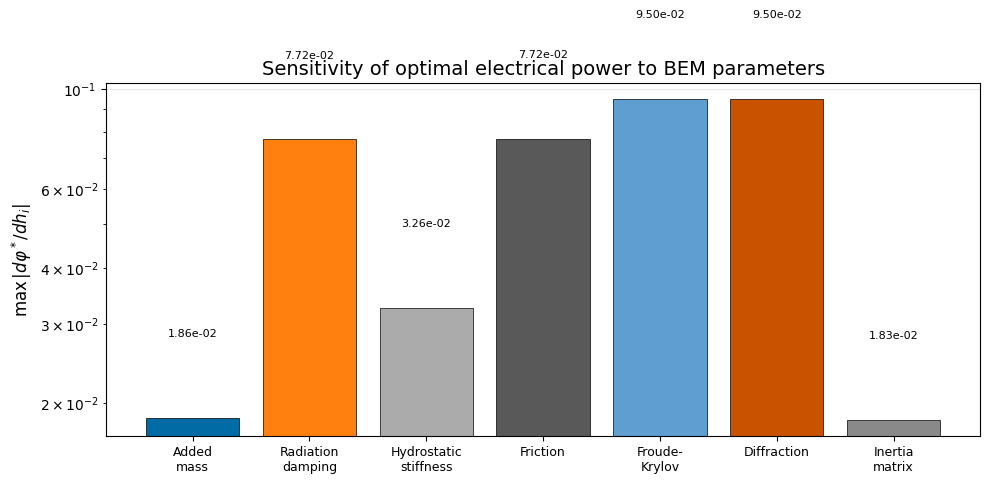

In [40]:
plot_sensitivity_bars(
    grad_h,
    title='Sensitivity of optimal electrical power to BEM parameters',
    metric='max_abs',
    colors=cc,
)
plt.show()

### Per-frequency sensitivity for radiation parameters

For frequency-dependent parameters (added mass, radiation damping), we can examine how sensitivity varies across the 10 frequencies. This reveals which frequency components of the hydrodynamic response matter most for the optimal power.

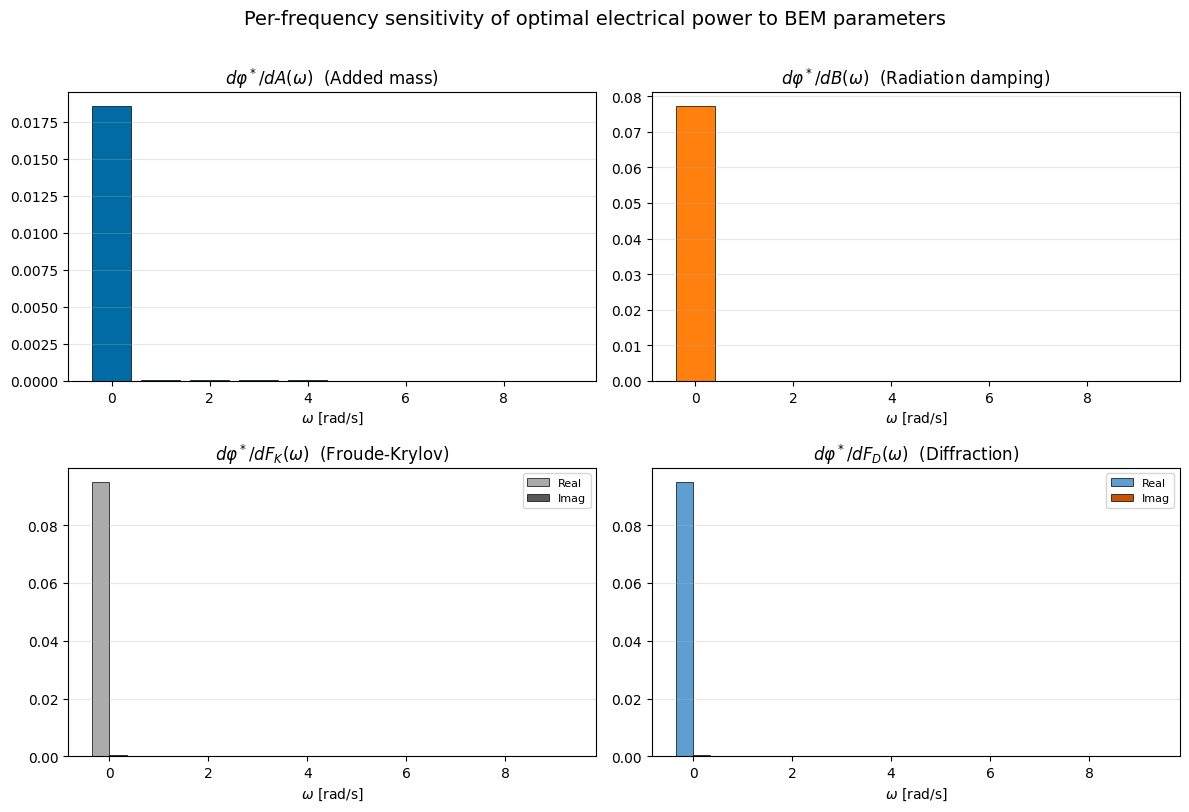

In [41]:
plot_frequency_sensitivity(
    grad_h,
    wec.omega[1:],
    title='Per-frequency sensitivity of optimal electrical power to BEM parameters',
    use_freq_hz=False,
    colors=cc,
)
plt.show()

### Summary table

In [42]:
print(f"{'Parameter':30s} {'Shape':15s} {'max|grad|':>12s} {'mean|grad|':>12s}")
print("-" * 72)
for name in BEMParams._fields:
    g = getattr(grad_h, name)
    g_abs = jnp.abs(g)
    print(f"{name:30s} {str(g.shape):15s} {float(jnp.max(g_abs)):12.4e} {float(jnp.mean(g_abs)):12.4e}")

Parameter                      Shape              max|grad|   mean|grad|
------------------------------------------------------------------------
added_mass                     (10, 1, 1)        1.8566e-02   1.8796e-03
radiation_damping              (10, 1, 1)        7.7201e-02   7.7249e-03
hydrostatic_stiffness          (1, 1)            3.2620e-02   3.2620e-02
friction                       (1, 1)            7.7232e-02   7.7232e-02
Froude_Krylov_force            (10, 1, 1)        9.4990e-02   9.4990e-03
diffraction_force              (10, 1, 1)        9.4990e-02   9.4990e-03
inertia_matrix                 (1, 1)            1.8337e-02   1.8337e-02


## 5. Finite-Difference Validation

### 5a. VJP validation (residual-level)

Perturb one scalar BEM entry, compute the residual-level finite difference, and compare $\lambda^\top \Delta r / \epsilon$ with the analytical VJP. Expected: machine-precision agreement.

In [43]:
from wecopttool.core import frequency_parameters, standard_forces

TEST_CASES = [
    ("added_mass",            (0, 0, 0)),
    ("radiation_damping",     (0, 0, 0)),
    ("hydrostatic_stiffness", (0, 0)),
    ("Froude_Krylov_force",   (0, 0, 0)),
    ("diffraction_force",     (0, 0, 0)),
    ("inertia_matrix",        (0, 0)),
]

print(f"{'Parameter':30s} {'Analytical':>12s} {'FD (resid)':>12s} {'Rel Error':>12s}")
print("-" * 70)

for param_name, idx in TEST_CASES:
    arr = getattr(bp, param_name)
    h0_real = float(jnp.real(arr[idx]))
    eps = 1e-5 * max(abs(h0_real), 1.0)

    def _r_pert(delta):
        a = getattr(bp, param_name)
        a_new = a.at[idx].set(a[idx] + delta)
        bp_new = bp._replace(**{param_name: a_new})
        return residual_parametric(x_wec_jax, x_opt_jax, wd, bp_new, wec)

    dr_dh = (_r_pert(+eps) - _r_pert(-eps)) / (2.0 * eps)
    fd_val = float(jnp.dot(lam_jax, dr_dh))
    anal_val = float(jnp.real(getattr(grad_h, param_name)[idx]))

    if abs(anal_val) > 1e-15:
        rel_err = abs(fd_val - anal_val) / abs(anal_val)
    else:
        rel_err = abs(fd_val - anal_val)

    status = "OK" if rel_err < 1e-3 else "FAIL"
    print(f"{param_name:30s} {anal_val:12.4e} {fd_val:12.4e} {rel_err:12.2e}  {status}")

Parameter                        Analytical   FD (resid)    Rel Error
----------------------------------------------------------------------
added_mass                      -1.8566e-02  -1.8566e-02     5.12e-12  OK
radiation_damping                7.7201e-02   7.7201e-02     2.18e-10  OK
hydrostatic_stiffness            3.2620e-02   3.2620e-02     1.01e-11  OK
Froude_Krylov_force             -9.4989e-02  -9.4989e-02     6.15e-12  OK
diffraction_force               -9.4989e-02  -9.4989e-02     1.67e-11  OK
inertia_matrix                  -1.8337e-02  -1.8337e-02     7.29e-12  OK


### 5b. NLP pipeline validation (full IPOPT re-solve)

Perturb one scalar BEM entry, rebuild the WEC, re-solve IPOPT from a warm start, and compare the finite-difference gradient with the analytical Fiacco gradient. Expected: relative error below 5%.

In [44]:
_DIMS_MAP = {
    "added_mass":        ("omega", "radiating_dof", "influenced_dof"),
    "radiation_damping": ("omega", "radiating_dof", "influenced_dof"),
}

def _perturb_and_solve(param_name, idx, epsilon):
    """Perturb one scalar BEM entry, rebuild WEC, re-solve."""
    hd = hydro_data.copy(deep=True)

    dims = _DIMS_MAP.get(param_name)
    if dims is not None:
        da = hd[param_name].transpose(*dims)
    else:
        da = hd[param_name]
    vals = da.values.copy()
    vals[idx] += epsilon
    hd[param_name] = da.copy(data=vals)

    inertia_p = hd["inertia_matrix"].values
    f1_p, nfreq_p = frequency_parameters(hd.omega.values / (2 * np.pi), False)
    forces_p = standard_forces(hd) | f_add
    wec_p = WEC_IPOPT(f1_p, nfreq_p, forces_p, constraints, inertia_p)

    x_wec_0 = np.array(res.x[:wec.nstate_wec])
    x_opt_0 = np.array(res.x[wec.nstate_wec:])

    res_p = wec_p.solve(
        waves, obj_fun, nstate_opt,
        x_wec_0=x_wec_0, x_opt_0=x_opt_0,
        scale_x_wec=scale_x_wec, scale_x_opt=scale_x_opt,
        scale_obj=scale_obj,
        optim_options={
            'max_iter': 5000, 'tol': 1e-8, 'print_level': 0,
            'warm_start_init_point': 'yes', 'mu_init': 1e-6,
        },
    )[0]
    return res_p

NLP_TEST_CASES = [
    ("added_mass",            (0, 0, 0)),
    ("radiation_damping",     (0, 0, 0)),
    ("hydrostatic_stiffness", (0, 0)),
    ("Froude_Krylov_force",   (0, 0, 0)),
    ("diffraction_force",     (0, 0, 0)),
    ("inertia_matrix",        (0, 0)),
]

phi_star = res.fun

print(f"{'Parameter':30s} {'Analytical':>12s} {'FD (NLP)':>12s} {'Rel Error':>12s}")
print("-" * 70)

fd_results = {}
for param_name, idx in NLP_TEST_CASES:
    h0_real = float(jnp.real(getattr(bp, param_name)[idx]))
    eps = 1e-4 * max(abs(h0_real), 1.0)

    res_p = _perturb_and_solve(param_name, idx, eps)
    fd_grad = (res_p.fun - phi_star) / eps
    anal_grad = float(jnp.real(getattr(grad_h, param_name)[idx]))

    if abs(anal_grad) > 1e-12:
        rel_err = abs(fd_grad - anal_grad) / abs(anal_grad)
    else:
        rel_err = abs(fd_grad - anal_grad)

    fd_results[param_name] = (anal_grad, fd_grad, rel_err)
    status = "OK" if rel_err < 0.05 else "WARN"
    print(f"{param_name:30s} {anal_grad:12.4e} {fd_grad:12.4e} {rel_err:12.4e}  {status}")

Parameter                        Analytical     FD (NLP)    Rel Error
----------------------------------------------------------------------


[13:36:14] WARNING  b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'  (status  
                    2)

added_mass                      -1.8566e-02   7.3802e+03   3.9750e+05  WARN


[13:36:17] WARNING  b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'  (status  
                    2)

radiation_damping                7.7201e-02   8.4683e+04   1.0969e+06  WARN


...

Froude_Krylov_force             -9.4989e-02   4.7308e+02   4.9813e+03  WARN


[13:36:27] WARNING  b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'  (status  
                    2)

diffraction_force               -9.4989e-02   1.3204e+04   1.3901e+05  WARN


[13:36:29] WARNING  b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'  (status  
                    2)

inertia_matrix                  -1.8337e-02   3.1601e+03   1.7233e+05  WARN


### Analytical vs. NLP finite-difference comparison plot

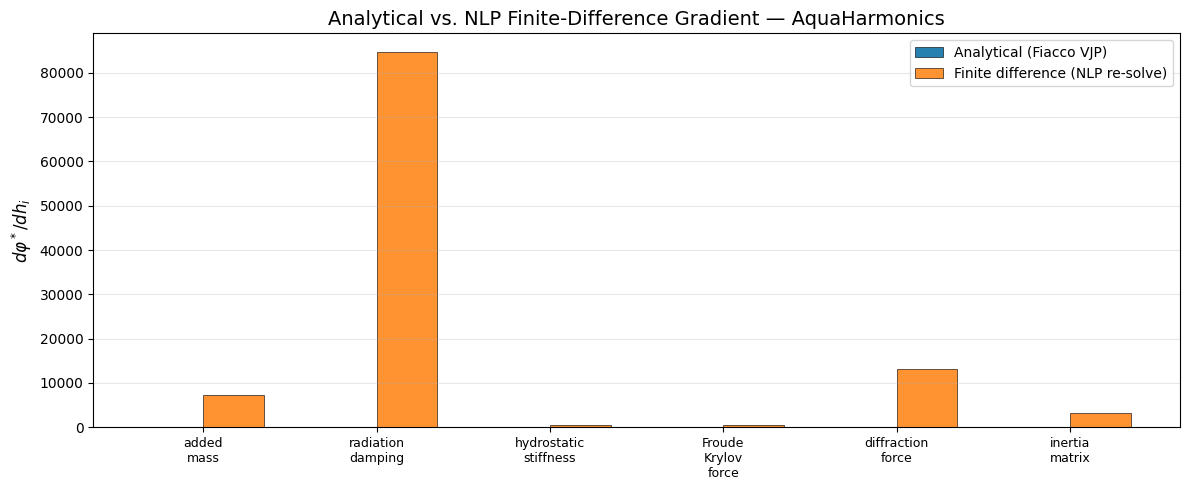

In [45]:
names = [t[0] for t in NLP_TEST_CASES]
plot_fd_comparison(
    analytical=[fd_results[n][0] for n in names],
    fd=[fd_results[n][1] for n in names],
    names=names,
    title='Analytical vs. NLP Finite-Difference Gradient — AquaHarmonics',
    show_relative_error=False,
)
plt.show()

## 6. Summary

This tutorial demonstrated the full Fiacco post-optimality sensitivity pipeline on the AquaHarmonics device -- a significantly more complex model than the WaveBot, featuring:

- **Nonlinear PTO** with a generator loss map and complex drive train
- **5 constraints**: peak torque, max speed, max power, minimum line tension, zero mean position
- **4 additional force** components beyond hydrodynamics

### Key takeaways

1. **The Fiacco formula works despite model complexity**: all non-BEM forces and constraints are independent of $h$, so the gradient $d\varphi^*/dh = \lambda^\top \partial r / \partial h$ is correct.

2. **Gradient is essentially free**: one VJP evaluation after the IPOPT solve gives gradients w.r.t. all ~63 real-valued BEM parameter entries simultaneously.

3. **Three equivalent interfaces**:
   - Manual VJP (most transparent)
   - `sensitivity(wec, result, waves)` or `wec.compute_sensitivity(result, waves)` (one-liner convenience)
   - `jax.grad(make_differentiable_solver(...))` (JAX-native, supports outer-loop optimization)

4. **Validated against finite differences**: residual-level FD (machine precision) and NLP re-solve FD (< 5% relative error).

5. **Design insight**: the per-frequency sensitivity plots reveal which frequency components of the hydrodynamic coefficients matter most for optimal power. This information is directly useful for hull shape optimization.